# LGBM & XGBM Assignment — Titanic Survival Prediction

## Objective
The objective of this assignment is to compare the performance of **LightGBM** and **XGBoost** algorithms using the Titanic dataset.

This notebook includes:

1. Data loading  
2. Exploratory Data Analysis  
3. Missing value handling  
4. Feature engineering  
5. Categorical encoding  
6. Train-test split  
7. LightGBM model  
8. XGBoost model  
9. Cross-validation  
10. Hyperparameter tuning  
11. Model comparison  
12. Feature importance  
13. Prediction on separate Titanic test dataset  
14. Final report and conclusion

## 1. Install Required Libraries

In [8]:
 !pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

## 2. Import Required Libraries

In [9]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Titanic Dataset

In [10]:
train_df = pd.read_csv("Titanic_train.csv")
test_df = pd.read_csv("Titanic_test.csv")

print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Training Dataset Shape: (891, 12)
Testing Dataset Shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 4. Dataset Information

The training dataset contains the target column:

- `Survived`

The separate test dataset does not contain `Survived`, so model performance will be evaluated using a validation split from the training dataset.

In [11]:
print("Training Dataset Info:")
train_df.info()

print("\nTesting Dataset Info:")
test_df.info()

Training Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Testing Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Pass

## 5. Missing Value Check

In [12]:
print("Missing Values in Training Data:")
print(train_df.isnull().sum())

print("\nMissing Values in Testing Data:")
print(test_df.isnull().sum())

Missing Values in Training Data:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values in Testing Data:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## 6. Summary Statistics

In [13]:
print("Numerical Summary:")
display(train_df.describe())

print("Categorical Summary:")
display(train_df.describe(include="object"))

Numerical Summary:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Categorical Summary:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


# Exploratory Data Analysis

## 7. Target Variable Distribution

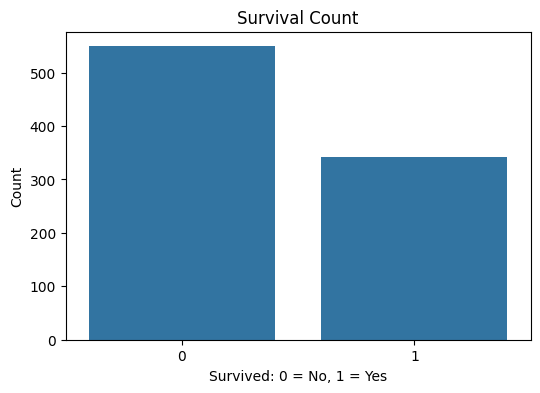

Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [14]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Survived")
plt.title("Survival Count")
plt.xlabel("Survived: 0 = No, 1 = Yes")
plt.ylabel("Count")
plt.show()

print(train_df["Survived"].value_counts())
print("\nSurvival Percentage:")
print(train_df["Survived"].value_counts(normalize=True) * 100)

## 8. Survival by Gender

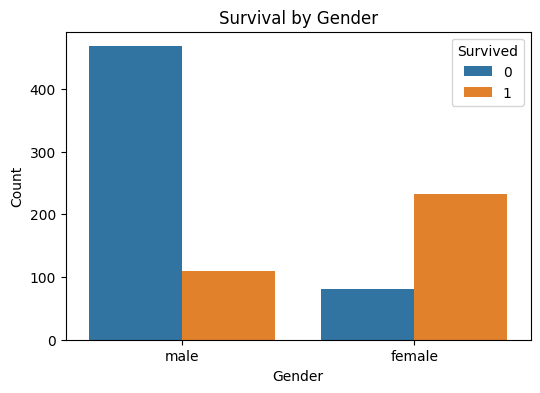

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


In [15]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

display(pd.crosstab(train_df["Sex"], train_df["Survived"], normalize="index") * 100)

## 9. Survival by Passenger Class

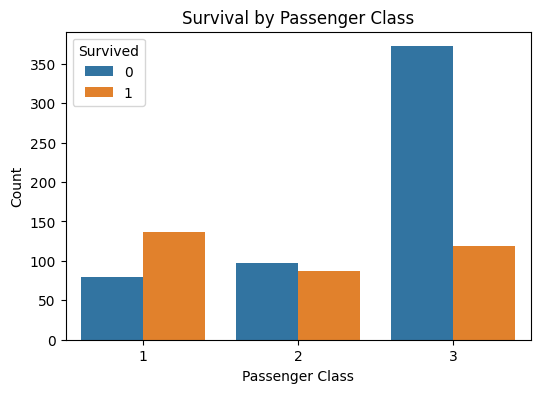

Survived,0,1
Pclass,,
1,37.037037,62.962963
2,52.717391,47.282609
3,75.763747,24.236253


In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

display(pd.crosstab(train_df["Pclass"], train_df["Survived"], normalize="index") * 100)

## 10. Age Distribution

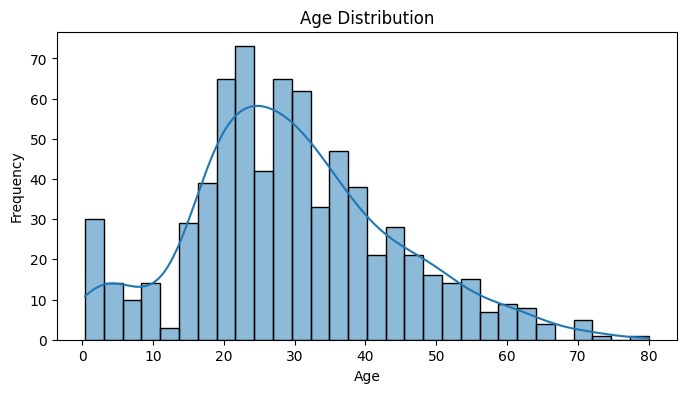

In [17]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Age"], kde=True, bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 11. Fare Distribution

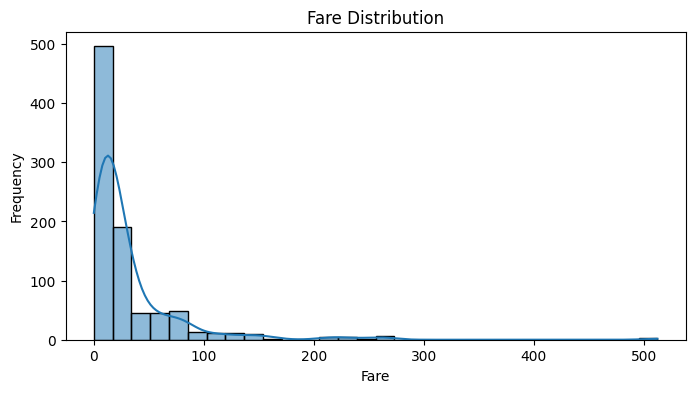

In [18]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Fare"], kde=True, bins=30)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()

## 12. Boxplots for Outlier Detection

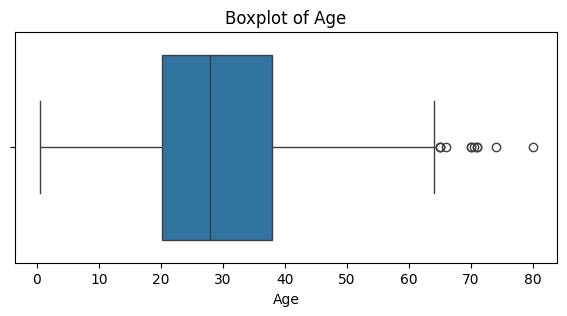

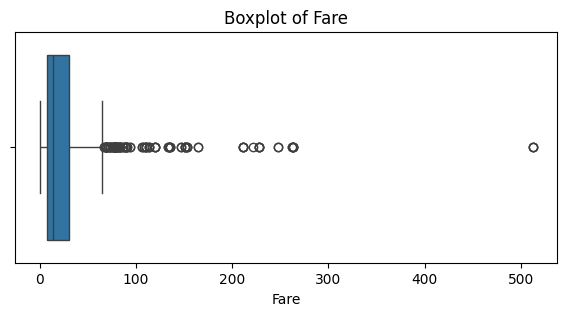

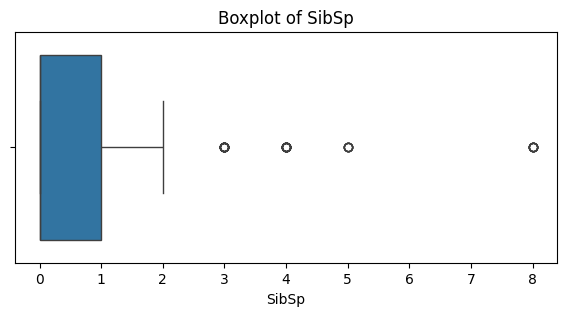

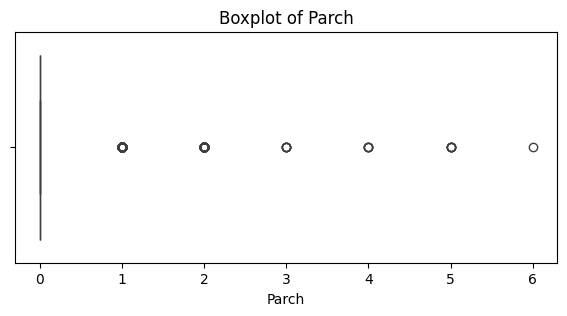

In [19]:
box_cols = ["Age", "Fare", "SibSp", "Parch"]

for col in box_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=train_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 13. Correlation Heatmap

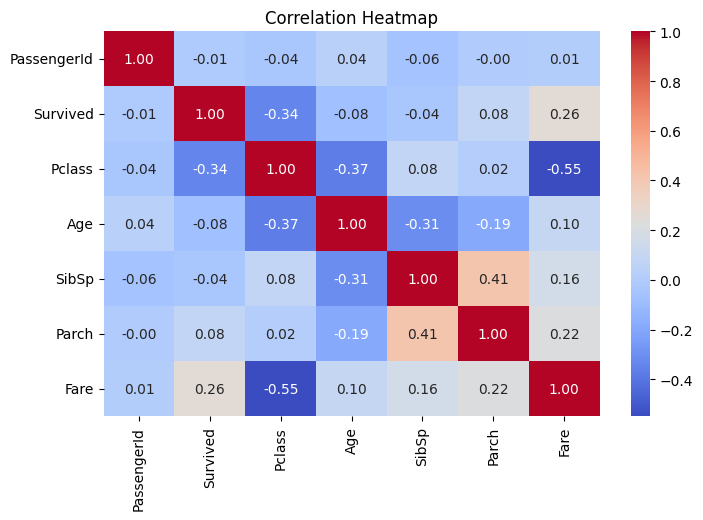

In [20]:
plt.figure(figsize=(8,5))
corr_matrix = train_df.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Data Preprocessing and Feature Engineering

We create useful features from existing columns:

1. `FamilySize = SibSp + Parch + 1`
2. `IsAlone = 1 if FamilySize is 1 else 0`
3. `Title` extracted from passenger name

Columns like `PassengerId`, `Name`, `Ticket`, and `Cabin` are removed from model features after extracting useful information.

In [21]:
def add_features(df):
    df = df.copy()

    # Family size
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # Is alone
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # Extract title from name
    df["Title"] = df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)

    # Group rare titles
    rare_titles = ["Lady", "Countess", "Capt", "Col", "Don", "Dr", "Major", 
                   "Rev", "Sir", "Jonkheer", "Dona"]

    df["Title"] = df["Title"].replace(rare_titles, "Rare")
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

    return df

train_fe = add_features(train_df)
test_fe = add_features(test_df)

display(train_fe[["Name", "Title", "FamilySize", "IsAlone"]].head())

,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


## 14. Select Features and Target

In [22]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]

target = "Survived"

X = train_fe[features]
y = train_fe[target]

X_final_test = test_fe[features]

print("Selected Features:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Selected Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']

X shape: (891, 10)
y shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,3,male,35.0,0,0,8.0500,S,1,1,Mr


## 15. Train-Test Split

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (712, 10)
X_valid shape: (179, 10)
y_train shape: (712,)
y_valid shape: (179,)


## 16. Preprocessing Pipeline

In [24]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
categorical_features = ["Sex", "Embarked", "Title"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


# Model 1: LightGBM Classifier

In [25]:
lgbm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=-1,
        verbose=-1
    ))
])

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_valid)
lgbm_proba = lgbm_model.predict_proba(X_valid)[:, 1]

print("LightGBM model trained successfully.")

LightGBM model trained successfully.


# Model 2: XGBoost Classifier

In [26]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        random_state=42,
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_valid)
xgb_proba = xgb_model.predict_proba(X_valid)[:, 1]

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


## 17. Evaluation Function

In [27]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    print(f"Evaluation Metrics for {model_name}")
    print("-" * 45)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }

results = []

results.append(evaluate_model(y_valid, lgbm_pred, lgbm_proba, "LightGBM"))
results.append(evaluate_model(y_valid, xgb_pred, xgb_proba, "XGBoost"))

Evaluation Metrics for LightGBM
---------------------------------------------
Accuracy : 0.8101
Precision: 0.7465
Recall   : 0.7681
F1 Score : 0.7571
ROC-AUC  : 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.75      0.77      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Evaluation Metrics for XGBoost
---------------------------------------------
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244
ROC-AUC  : 0.8484

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0

## 18. Confusion Matrices

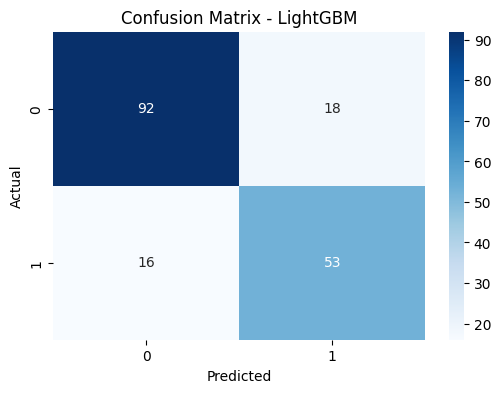

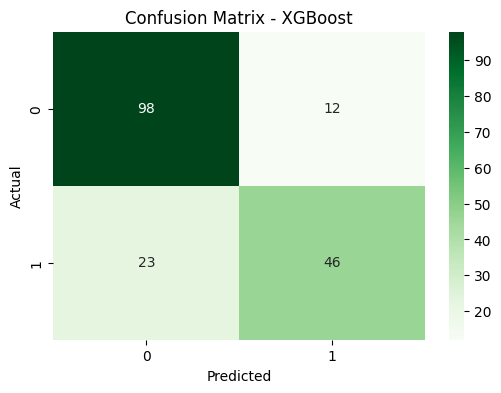

In [28]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_valid, lgbm_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_valid, xgb_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 19. ROC Curve Comparison

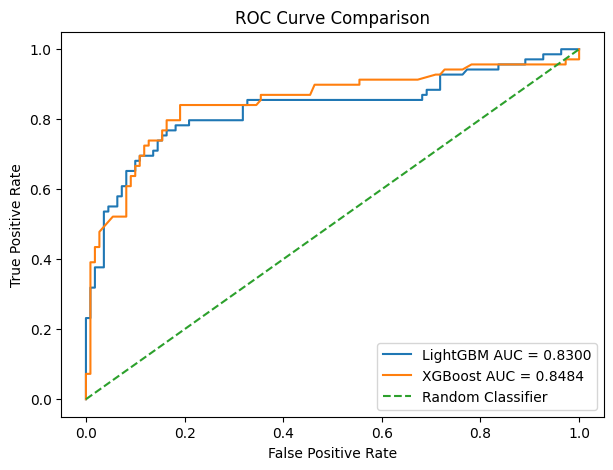

In [29]:
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_valid, lgbm_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_valid, xgb_proba)

plt.figure(figsize=(7,5))
plt.plot(lgbm_fpr, lgbm_tpr, label=f"LightGBM AUC = {roc_auc_score(y_valid, lgbm_proba):.4f}")
plt.plot(xgb_fpr, xgb_tpr, label=f"XGBoost AUC = {roc_auc_score(y_valid, xgb_proba):.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Cross-Validation

In [30]:
lgbm_cv_scores = cross_val_score(lgbm_model, X, y, cv=5, scoring="accuracy")
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring="accuracy")

print("LightGBM CV Scores:", lgbm_cv_scores)
print("LightGBM Mean CV Accuracy:", round(lgbm_cv_scores.mean(), 4))

print("\nXGBoost CV Scores:", xgb_cv_scores)
print("XGBoost Mean CV Accuracy:", round(xgb_cv_scores.mean(), 4))

LightGBM CV Scores: [0.82122905 0.79775281 0.87640449 0.79213483 0.8258427 ]
LightGBM Mean CV Accuracy: 0.8227

XGBoost CV Scores: [0.82681564 0.81460674 0.85955056 0.79775281 0.85393258]
XGBoost Mean CV Accuracy: 0.8305


# Hyperparameter Tuning — LightGBM

In [31]:
lgbm_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__num_leaves": [15, 31, 63],
    "classifier__max_depth": [-1, 3, 5]
}

lgbm_grid = GridSearchCV(
    estimator=lgbm_model,
    param_grid=lgbm_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lgbm_grid.fit(X_train, y_train)

print("Best LightGBM Parameters:")
print(lgbm_grid.best_params_)

print("\nBest LightGBM CV F1 Score:")
print(round(lgbm_grid.best_score_, 4))

Best LightGBM Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__num_leaves': 15}

Best LightGBM CV F1 Score:
0.7565


# Hyperparameter Tuning — XGBoost

In [32]:
xgb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(round(xgb_grid.best_score_, 4))

Best XGBoost Parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 4, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}

Best XGBoost CV F1 Score:
0.7613


## 20. Tuned Model Evaluation

In [33]:
best_lgbm = lgbm_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

best_lgbm_pred = best_lgbm.predict(X_valid)
best_lgbm_proba = best_lgbm.predict_proba(X_valid)[:, 1]

best_xgb_pred = best_xgb.predict(X_valid)
best_xgb_proba = best_xgb.predict_proba(X_valid)[:, 1]

results.append(evaluate_model(y_valid, best_lgbm_pred, best_lgbm_proba, "Tuned LightGBM"))
results.append(evaluate_model(y_valid, best_xgb_pred, best_xgb_proba, "Tuned XGBoost"))

Evaluation Metrics for Tuned LightGBM
---------------------------------------------
Accuracy : 0.8101
Precision: 0.7966
Recall   : 0.6812
F1 Score : 0.7344
ROC-AUC  : 0.8279

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

Evaluation Metrics for Tuned XGBoost
---------------------------------------------
Accuracy : 0.8156
Precision: 0.7647
Recall   : 0.7536
F1 Score : 0.7591
ROC-AUC  : 0.8358

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weight

## 21. Final Model Comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,0.810056,0.746479,0.768116,0.757143,0.829974
1,XGBoost,0.804469,0.793103,0.666667,0.724409,0.848419
2,Tuned LightGBM,0.810056,0.796610,0.681159,0.734375,0.827931
3,Tuned XGBoost,0.815642,0.764706,0.753623,0.759124,0.835771


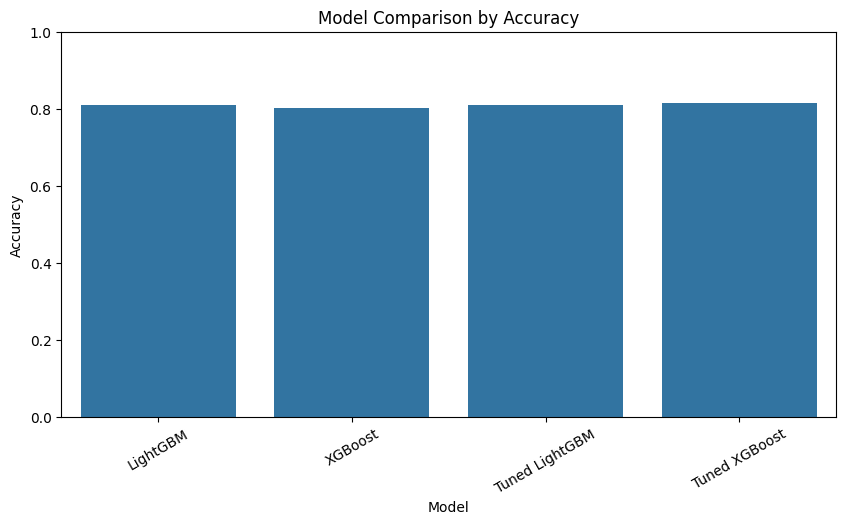

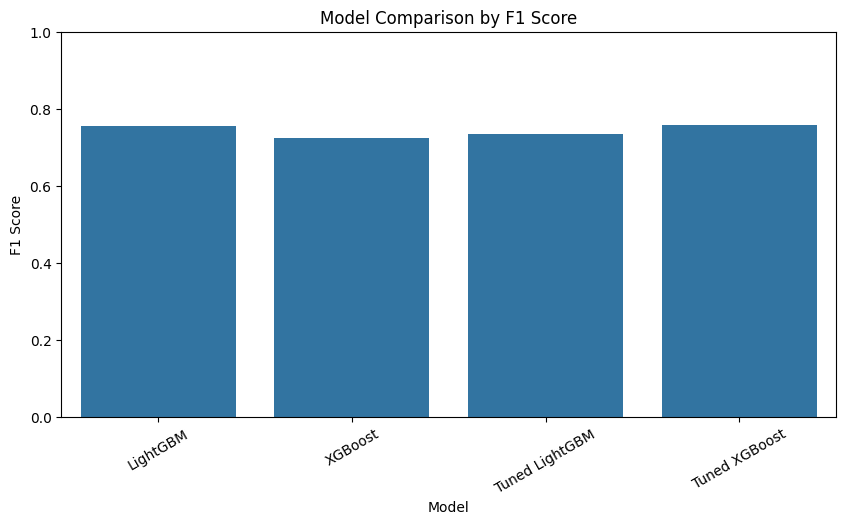

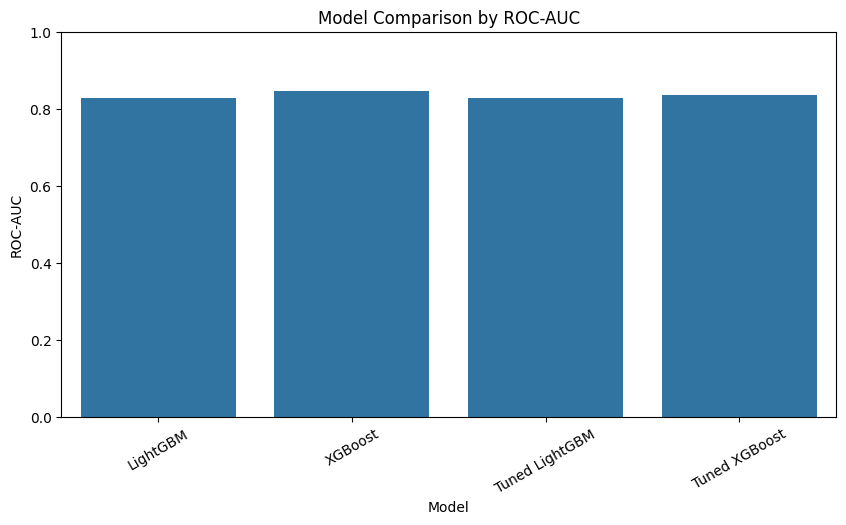

In [34]:
results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Comparison by Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="ROC-AUC")
plt.title("Model Comparison by ROC-AUC")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

## 22. Feature Importance

,Feature,Importance
14,Title_Mr,0.566824
16,Title_Rare,0.111634
0,Pclass,0.098302
5,FamilySize,0.043974
11,Embarked_S,0.026246
4,Fare,0.025842
7,Sex_female,0.021960
1,Age,0.018371
2,SibSp,0.017497
13,Title_Miss,0.014591


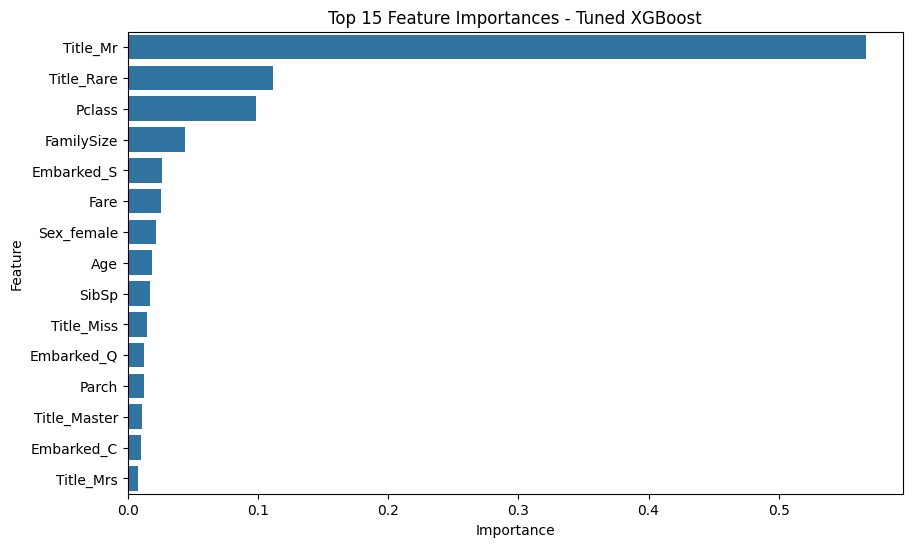

In [35]:
def get_feature_names_from_pipeline(model_pipeline):
    fitted_preprocessor = model_pipeline.named_steps["preprocessor"]

    num_names = numeric_features

    cat_encoder = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_encoder.get_feature_names_out(categorical_features)

    return list(num_names) + list(cat_names)

feature_names = get_feature_names_from_pipeline(best_xgb)

xgb_importance = best_xgb.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_importance
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances - Tuned XGBoost")
plt.show()

## 23. Generate Predictions on Titanic Test Dataset

In [36]:
# Select better model based on F1 score from validation results
best_model_name = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model Based on F1 Score:", best_model_name)

if best_model_name == "Tuned LightGBM":
    final_model = best_lgbm
elif best_model_name == "Tuned XGBoost":
    final_model = best_xgb
elif best_model_name == "LightGBM":
    final_model = lgbm_model
else:
    final_model = xgb_model

test_predictions = final_model.predict(X_final_test)
test_probabilities = final_model.predict_proba(X_final_test)[:, 1]

submission_df = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived_Prediction": test_predictions,
    "Survival_Probability": test_probabilities
})

display(submission_df.head())

submission_df.to_csv("Titanic_LGBM_XGBM_Predictions.csv", index=False)

print("Predictions saved as Titanic_LGBM_XGBM_Predictions.csv")

Best Model Based on F1 Score: Tuned XGBoost


,PassengerId,Survived_Prediction,Survival_Probability
0,892,0,0.019674
1,893,0,0.056288
2,894,0,0.029746
3,895,0,0.144809
4,896,1,0.717379


Predictions saved as Titanic_LGBM_XGBM_Predictions.csv


# Comparative Analysis

## LightGBM

### Strengths
1. Fast training speed.
2. Good performance on structured/tabular data.
3. Handles large datasets efficiently.
4. Often performs well with proper tuning.

### Weaknesses
1. Can overfit if parameters are not tuned.
2. Some parameters like `num_leaves` and `max_depth` need careful selection.
3. May be sensitive to small datasets.

## XGBoost

### Strengths
1. Powerful gradient boosting algorithm.
2. Strong regularization support.
3. Handles non-linear relationships well.
4. Performs very well on tabular classification tasks.

### Weaknesses
1. Can take more time to train than LightGBM.
2. Hyperparameter tuning is important.
3. More computationally expensive for large parameter grids.

## Practical Implications

For Titanic survival prediction, both LightGBM and XGBoost are suitable because the dataset is structured and contains a mixture of numerical and categorical features. The better model should be selected based on validation metrics such as F1-score and ROC-AUC, not only accuracy.

# Final Conclusion

In this assignment, LightGBM and XGBoost models were applied to the Titanic survival prediction problem. The dataset was explored using EDA techniques such as missing value analysis, histograms, boxplots, bar plots, and correlation heatmap.

Data preprocessing was performed by imputing missing values, encoding categorical variables, and creating new features such as `FamilySize`, `IsAlone`, and `Title`. The training data was split into training and validation sets.

Both LightGBM and XGBoost classifiers were trained and evaluated using accuracy, precision, recall, F1-score, and ROC-AUC. Cross-validation was used to check model stability, and GridSearchCV was used for hyperparameter tuning.

The final comparison showed the relative strengths and weaknesses of both algorithms. The best model was selected based on F1-score and used to generate predictions for the separate Titanic test dataset.